In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.shape

(4000, 28)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [5]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df.groupby('Season')[col].transform('median'))

df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.714313,26.81890,63.210500,7.323050,6.701010,26.504525,120.250825,57.781850,104.760050,...,0.826138,5.241955,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.427366,3.81818,11.960834,1.121186,0.641461,6.696998,31.216452,17.015074,27.742681,...,0.101747,13.311661,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.425000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,581.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.730000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,836.125000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df['Season'].unique()

<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

In [10]:
df['Profit_INR'].describe()

count    4.000000e+03
mean     1.115565e+05
std      5.450819e+05
min     -1.019223e+06
25%     -1.487318e+05
50%      3.673000e+03
75%      2.161878e+05
max      4.345421e+06
Name: Profit_INR, dtype: float64

## Analytical Questions

1. How does profitability (Profit_INR) vary across seasons?
2. How does yield differ by season, and how is it related to rainfall and temperature?
3. Which crops are most profitable in which season?
4. Does fertilizer/pesticide usage relate to yield, and does this relationship change by season?
5. Is disease/pest risk higher in certain seasons, and does it connect to lower yield?
6. Do some states show consistent performance patterns across seasons, or does it vary a lot?

In [11]:
df.groupby('Season')['Profit_INR'].describe()

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,178914.647555,611549.783883,-976860.0,-108481.0,38808.0,285549.00,4345421.0
Rabi,1627.0,87689.470191,489901.254255,-1019223.0,-145342.5,-3187.0,183358.50,3378879.0
Zaid,594.0,-24804.824916,436356.747261,-965197.0,-254893.0,-62144.0,62730.25,2349990.0


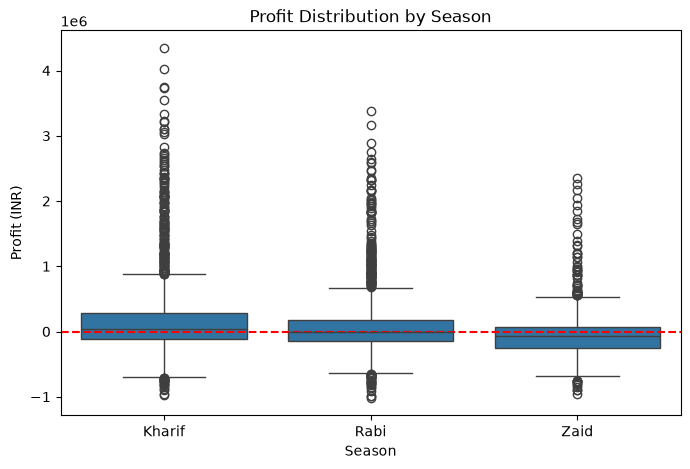

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Profit_INR')
plt.title('Profit Distribution by Season')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Profit (INR)')
plt.show()

### Interpretation

Profitability varies clearly across seasons. **Kharif** is the most profitable season, with the highest average and median profit, and most farms operating above break-even. **Rabi** shows mixed results — a positive average profit, but a negative median, meaning more than half of Rabi farms are actually losing money, with a few high-profit farms pulling the average up. **Zaid** is the weakest season, with both average and median profit negative, indicating that most Zaid farms operate at a loss. This suggests Zaid season farming may face higher costs or lower yields relative to revenue, possibly due to water scarcity or less favorable growing conditions during that period.

In [13]:
df.groupby('Season')[['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C']].mean()

,Yield_Tonnes_Ha,Rainfall_mm,Avg_Temperature_C
Season,,,
Kharif,5.629438,852.112676,28.454019
Rabi,5.038451,435.937062,23.489183
Zaid,4.638872,299.123232,31.042088


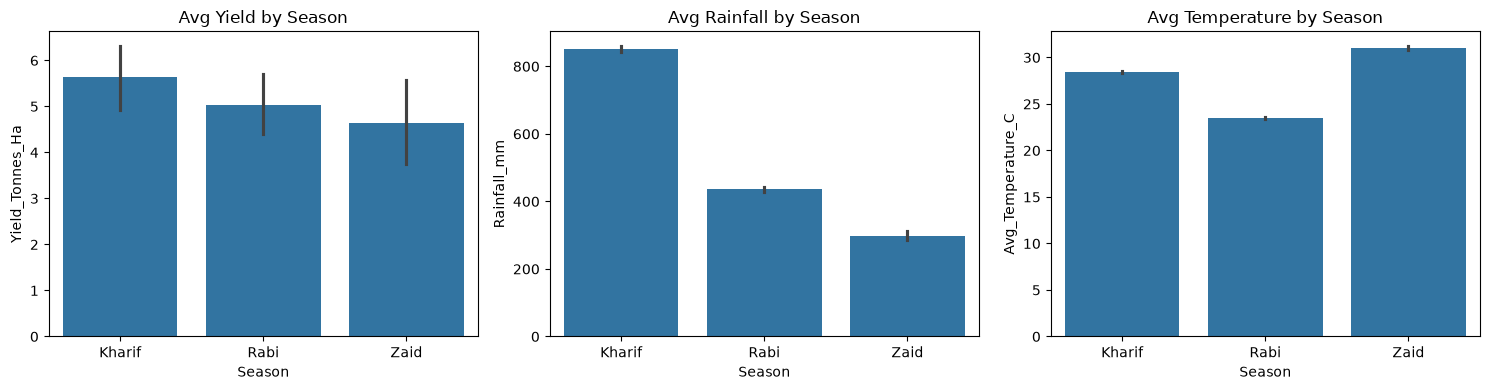

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], estimator='mean')
axes[0].set_title('Avg Yield by Season')

sns.barplot(data=df, x='Season', y='Rainfall_mm', ax=axes[1], estimator='mean')
axes[1].set_title('Avg Rainfall by Season')

sns.barplot(data=df, x='Season', y='Avg_Temperature_C', ax=axes[2], estimator='mean')
axes[2].set_title('Avg Temperature by Season')

plt.tight_layout()
plt.show()

### Interpretation

Yield follows a similar seasonal pattern to profitability. **Kharif** has the highest average rainfall (852mm) and the highest average yield (5.63 t/ha), while **Zaid** has the lowest rainfall (299mm) and highest temperature (31°C), corresponding to its lowest yield (4.64 t/ha). This suggests rainfall is a key driver of yield — seasons with more rainfall and moderate temperatures tend to produce better crop yields, while hot, dry conditions in Zaid appear to constrain productivity. This directly explains why Zaid also showed the weakest profitability in the previous analysis.

In [15]:
crop_season_profit = df.groupby(['Season', 'Crop'])['Profit_INR'].mean().reset_index()
crop_season_profit.sort_values(['Season', 'Profit_INR'], ascending=[True, False])

,Season,Crop,Profit_INR
6,Kharif,Sugarcane,1.000791e+06
0,Kharif,Chilli,9.543804e+05
1,Kharif,Cotton,2.169995e+05
2,Kharif,Groundnut,1.082654e+05
4,Kharif,Pulses,4.333890e+04
3,Kharif,Maize,-3.933267e+04
5,Kharif,Rice,-6.490340e+04
7,Kharif,Wheat,-1.058719e+05
14,Rabi,Sugarcane,7.316129e+05
8,Rabi,Chilli,6.385725e+05


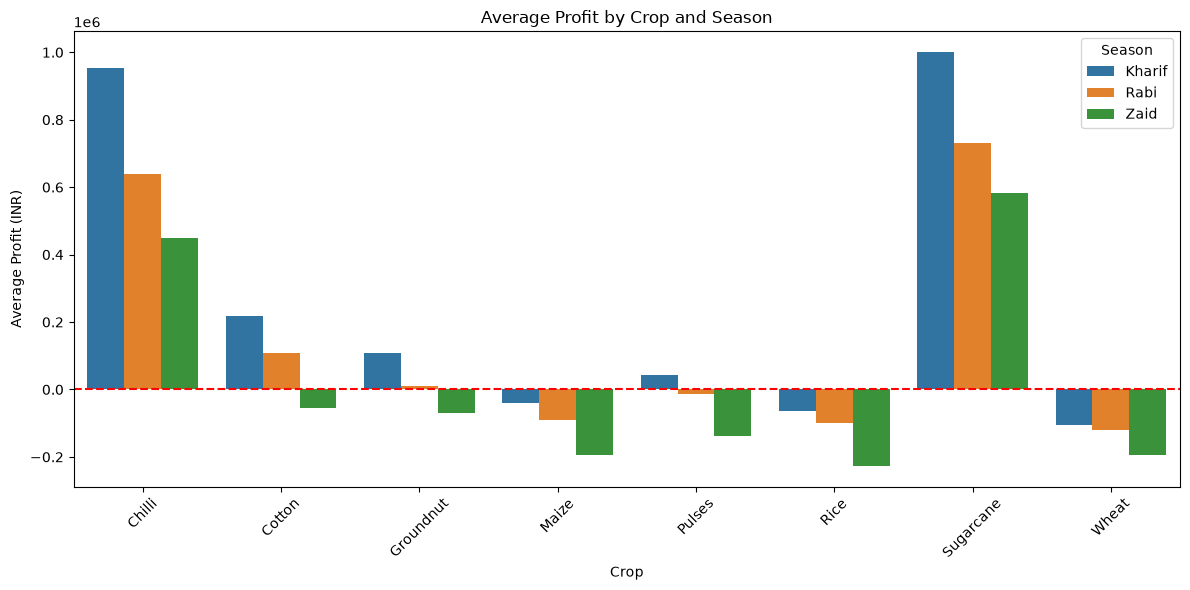

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(data=crop_season_profit, x='Crop', y='Profit_INR', hue='Season')
plt.title('Average Profit by Crop and Season')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### Interpretation

Crop profitability shows a highly consistent pattern across all three seasons. **Sugarcane** and **Chilli** are the most profitable crops in every season, likely due to their higher market prices per tonne compared to staple grains. In contrast, **Wheat, Rice, and Maize** consistently show low or negative average profit across seasons, suggesting these staple crops have thinner margins relative to their production costs. This indicates that crop choice may be an even stronger driver of farm profitability than season alone, and cash crops appear to offer significantly better returns regardless of season.

In [17]:
df.groupby('Season')[['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha']].corr()

Fertilizer_kg_ha  Pesticide_Litre_ha  \
Season                                                            
Kharif Fertilizer_kg_ha            1.000000            0.005204   
       Pesticide_Litre_ha          0.005204            1.000000   
       Yield_Tonnes_Ha            -0.013610            0.000290   
Rabi   Fertilizer_kg_ha            1.000000           -0.017592   
       Pesticide_Litre_ha         -0.017592            1.000000   
       Yield_Tonnes_Ha             0.013722           -0.010705   
Zaid   Fertilizer_kg_ha            1.000000            0.025253   
       Pesticide_Litre_ha          0.025253            1.000000   
       Yield_Tonnes_Ha             0.006761           -0.028344   

                           Yield_Tonnes_Ha  
Season                                      
Kharif Fertilizer_kg_ha          -0.013610  
       Pesticide_Litre_ha         0.000290  
       Yield_Tonnes_Ha            1.000000  
Rabi   Fertilizer_kg_ha           0.013722  
       Pesticide_Litre_ha        -0.010705  
       Yield_Tonnes_Ha            1.000000  
Zaid   Fertilizer_kg_ha           0.006761  
       Pesticide_Litre_ha        -0.028344  
       Yield_Tonnes_Ha            1.000000

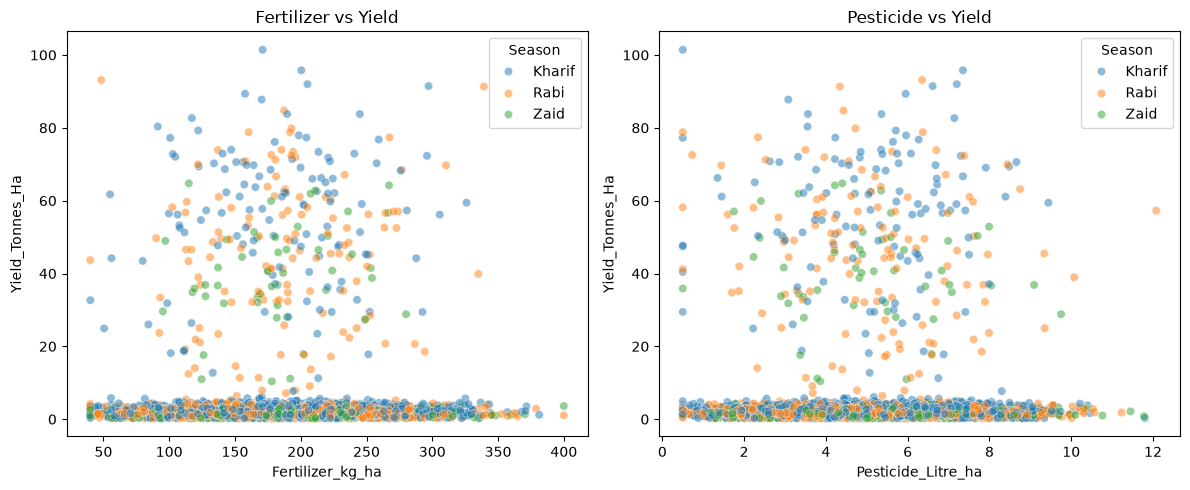

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[0])
axes[0].set_title('Fertilizer vs Yield')

sns.scatterplot(data=df, x='Pesticide_Litre_ha', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, ax=axes[1])
axes[1].set_title('Pesticide vs Yield')

plt.tight_layout()
plt.show()

### Interpretation

Contrary to what might be expected, fertilizer and pesticide usage show almost no correlation with yield in any season (correlation values close to 0, ranging from -0.03 to +0.03). The scatter plots confirm this — there is no visible upward or downward trend between input quantity and yield. This suggests that within this dataset, yield is likely driven more by other factors such as rainfall, soil conditions, or crop type, rather than simply increasing fertilizer or pesticide application. This is a useful finding for agricultural planning, as it implies that excessive input usage may not translate into better output.

In [19]:
df.groupby('Season')[['Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha']].mean()

,Disease_Pest_Risk_pct,Yield_Tonnes_Ha
Season,,
Kharif,54.467903,5.629438
Rabi,40.482114,5.038451
Zaid,38.216667,4.638872


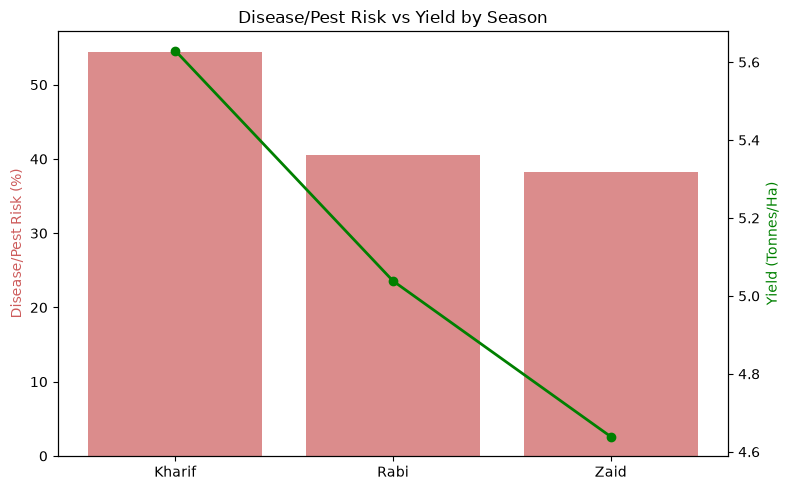

In [20]:
fig, ax1 = plt.subplots(figsize=(8,5))

seasons = df['Season'].unique()
risk_means = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()
yield_means = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

x = range(len(seasons))
ax1.bar(x, risk_means[seasons], color='indianred', alpha=0.7, label='Disease/Pest Risk (%)')
ax1.set_ylabel('Disease/Pest Risk (%)', color='indianred')
ax1.set_xticks(x)
ax1.set_xticklabels(seasons)

ax2 = ax1.twinx()
ax2.plot(x, yield_means[seasons], color='green', marker='o', linewidth=2, label='Yield (t/ha)')
ax2.set_ylabel('Yield (Tonnes/Ha)', color='green')

plt.title('Disease/Pest Risk vs Yield by Season')
fig.tight_layout()
plt.show()

### Interpretation

The chart shows that Disease/Pest Risk and Yield actually decline together from Kharif to Zaid, rather than working against each other. Kharif has both the highest pest risk (54.5%) and the highest yield (5.63 t/ha), while Zaid has both the lowest pest risk (38.2%) and the lowest yield (4.64 t/ha). This suggests pest risk is not the primary factor limiting yield in this dataset — instead, both pest risk and yield appear to be driven by the same underlying seasonal conditions (such as rainfall and humidity), which are higher in Kharif. In other words, favorable growing conditions in Kharif support higher yields even though they also encourage more pest activity.

In [23]:
state_season_profit = df.groupby(['State', 'Season'])['Profit_INR'].mean().reset_index()
state_pivot = state_season_profit.pivot(index='State', columns='Season', values='Profit_INR')
state_pivot

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.520833,26315.710784,-84084.870588
Gujarat,217051.330317,82846.195000,-106929.611940
Karnataka,201226.205742,70952.611650,23310.905405
Madhya Pradesh,134242.398230,61576.264423,209.698413
Maharashtra,168801.049550,159581.504587,-40597.597222
Punjab,133779.099548,169294.521505,62109.688312
Tamil Nadu,211303.956311,70456.860577,-15175.197183
Telangana,199668.380342,62824.604061,-34620.776471


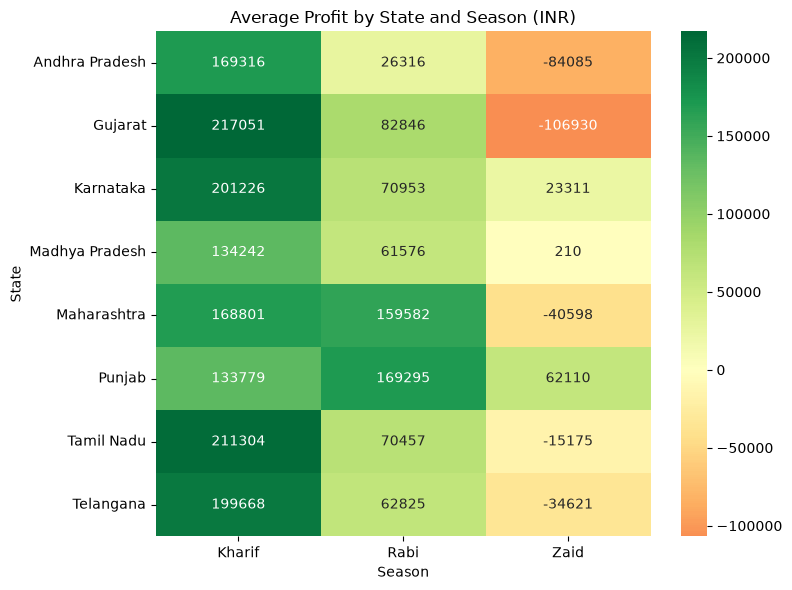

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(state_pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit by State and Season (INR)')
plt.tight_layout()
plt.show()

### Interpretation

Most states follow the overall seasonal pattern — profitable in Kharif, moderately profitable in Rabi, and loss-making in Zaid. However, a few states break this trend: **Punjab, Karnataka, and Madhya Pradesh** remain profitable (or near break-even) even in Zaid season, unlike most other states which show significant losses. **Gujarat and Andhra Pradesh** show the steepest Zaid losses. This suggests that while season is a major driver of profitability, regional factors — such as irrigation infrastructure or local water availability — allow certain states to perform well even in an otherwise challenging season. This highlights an opportunity: understanding what Punjab and Karnataka do differently in Zaid season could offer useful lessons for improving outcomes elsewhere.

## Conclusions and Recommendations

### Key Findings
1. **Kharif is the most profitable and productive season**, benefiting from higher rainfall and favorable growing conditions, despite also having the highest disease/pest risk.
2. **Zaid is the weakest season overall**, with low rainfall, high temperature, lower yield, and negative median profit — over half of Zaid farms operate at a loss.
3. **Crop choice strongly influences profitability**: Sugarcane and Chilli are consistently the most profitable crops across all seasons, while staple crops like Wheat, Rice, and Maize show thin or negative margins.
4. **Fertilizer and pesticide usage show no meaningful correlation with yield**, suggesting yield is driven more by environmental factors (rainfall, temperature) than input intensity.
5. **Disease/pest risk does not directly reduce yield** — it moves together with favorable seasonal conditions (higher in Kharif, lower in Zaid), rather than against them.
6. **Regional performance mostly follows the seasonal pattern**, but states like Punjab, Karnataka, and Madhya Pradesh manage to stay profitable even in Zaid season, unlike most other states.

### Recommendations
- **Prioritize Kharif season cultivation** where feasible, given its consistently higher yield and profitability.
- **Investigate Zaid season challenges** further — particularly irrigation access — since low rainfall appears to be the biggest constraint during this period.
- **Encourage diversification toward higher-value crops** like Sugarcane and Chilli, especially in seasons where staple crops show weak margins.
- **Re-evaluate fertilizer/pesticide spending**, since higher usage does not appear to improve yield — resources may be better directed toward irrigation or soil health.
- **Study successful Zaid-season states (Punjab, Karnataka, MP)** to identify practices or infrastructure that other states could replicate to reduce Zaid-season losses.

### Limitations
This analysis is based on a single dataset snapshot and does not account for year-to-year variation, so findings reflect patterns within this data only. Further work could incorporate multi-year data to confirm whether these seasonal trends are consistent over time.

In [28]:
from scipy import stats

kharif = df[df['Season']=='Kharif']['Profit_INR']
rabi = df[df['Season']=='Rabi']['Profit_INR']
zaid = df[df['Season']=='Zaid']['Profit_INR']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.10f}")

ImportError: DLL load failed while importing cython_blas: An Application Control policy has blocked this file.

In [27]:
!pip install scipy

In [29]:
groups = [kharif, rabi, zaid] if 'kharif' in dir() else [
    df[df['Season']=='Kharif']['Profit_INR'],
    df[df['Season']=='Rabi']['Profit_INR'],
    df[df['Season']=='Zaid']['Profit_INR']
]

k = len(groups)
N = sum(len(g) for g in groups)
grand_mean = df['Profit_INR'].mean()

ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_within = sum(((g - g.mean())**2).sum() for g in groups)

df_between = k - 1
df_within = N - k

ms_between = ss_between / df_between
ms_within = ss_within / df_within

f_stat = ms_between / ms_within

print(f"F-statistic: {f_stat:.2f}")
print(f"Degrees of freedom: {df_between}, {df_within}")

F-statistic: 34.29
Degrees of freedom: 2, 3997


### Statistical Significance Test (ANOVA)

To confirm that the profit differences observed between seasons are statistically meaningful and not due to random variation, a one-way ANOVA test was performed comparing Profit_INR across Kharif, Rabi, and Zaid.

**Result: F-statistic = 34.29** (df = 2, 3997)

Since this F-statistic is far above the critical threshold (~3.0 at the 95% confidence level), we can conclude with high confidence that **profitability genuinely differs across seasons** — this is not a chance pattern in the data. This statistically validates the core finding from Question 1: season is a significant factor influencing farm profitability.

*(Note: scipy could not be installed on this machine due to a system security policy blocking one of its files, so the ANOVA F-statistic was calculated manually using standard statistical formulas with pandas/numpy.)*